In [285]:
#! 1. Loaded an EEGLAB .set file into Python/MNE.

#The EEG had already been filtered in EEGLAB.

#The dataset already contained ICA information from EEGLAB.

#Channels included: O1, O2, Fp2, Fp1


#then Confirmed that MNE loaded the EEG signal correctly -> plotted

In [286]:
import mne
from mne.preprocessing import ICA
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [287]:
path = "/Users/sarah-rosemay/Documents/EEG_data/EEG_DATA_05_4_2026/Halo_4ch_ica.set"

raw = mne.io.read_raw_eeglab(path, preload=True)

print(raw)
print(raw.ch_names)
print(raw.info["sfreq"])

Reading /Users/sarah-rosemay/Documents/EEG_data/EEG_DATA_05_4_2026/Halo_4ch_ica.fdt
Reading 0 ... 66974  =      0.000 ...   267.896 secs...
<RawEEGLAB | Halo_4ch_ica.fdt, 4 x 66975 (267.9 s), ~2.1 MB, data loaded>
['O1', 'O2', 'Fp2', 'Fp1']
250.0


/var/folders/33/qg_ry0_n2kb_gsw589xg9z_w0000gn/T/ipykernel_22820/2929315400.py:3: RuntimeWarning: Estimated head radius (11.2 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(path, preload=True)


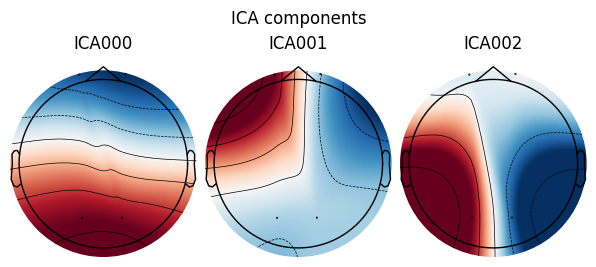

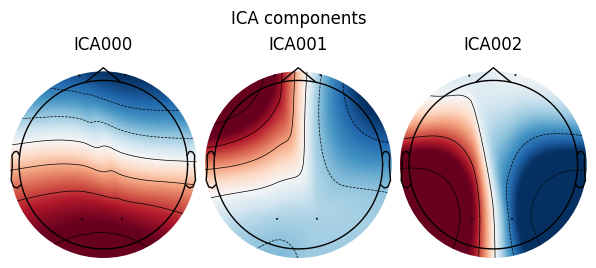

In [288]:
ica.plot_components()

In [289]:
# Accessed the original EEGLAB ICA information stored in the .set file.  Found: icaweights icasphere icawinv icaact

In [290]:
icaact = eeglab["icaact"]
icawinv = eeglab["icawinv"]
icaweights = eeglab["icaweights"]
icasphere = eeglab["icasphere"]

print("icaact shape:", icaact.shape)
print("icawinv shape:", icawinv.shape)
print("icaweights shape:", icaweights.shape)
print("icasphere shape:", icasphere.shape)

icaact shape: (0,)
icawinv shape: (4, 3)
icaweights shape: (3, 4)
icasphere shape: (4, 4)


In [291]:
data = np.array(eeglab["data"])
icaweights = np.array(eeglab["icaweights"])
icasphere = np.array(eeglab["icasphere"])

print("data shape:", data.shape)
print("icaweights shape:", icaweights.shape)
print("icasphere shape:", icasphere.shape)

#Determined that EEGLAB had not directly saved the ICA activations (icaact was empty)

data shape: ()
icaweights shape: (3, 4)
icasphere shape: (4, 4)


In [292]:
data = raw.get_data()

icaweights = np.array(eeglab["icaweights"], dtype=float)
icasphere = np.array(eeglab["icasphere"], dtype=float)

print("data shape:", data.shape)
print("icaweights shape:", icaweights.shape)
print("icasphere shape:", icasphere.shape)

data shape: (4, 66975)
icaweights shape: (3, 4)
icasphere shape: (4, 4)


In [293]:
unmixing = icaweights @ icasphere
icaact_reconstructed = unmixing @ data

print("Reconstructed EEGLAB ICA shape:", icaact_reconstructed.shape)

# Reconstructed the ORIGINAL EEGLAB ICA component activity using: ICA weights × ICA sphere × EEG data.

Reconstructed EEGLAB ICA shape: (3, 66975)


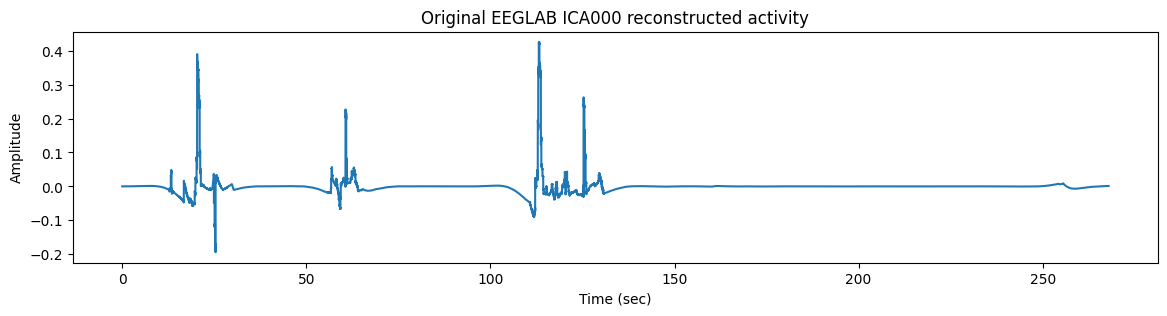

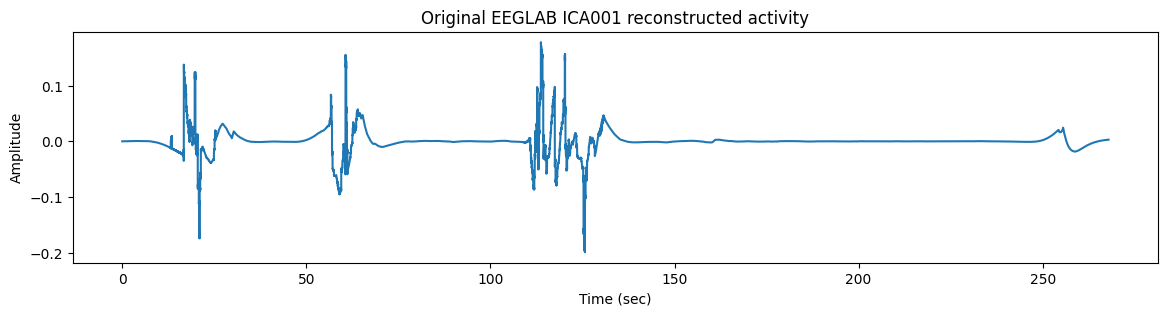

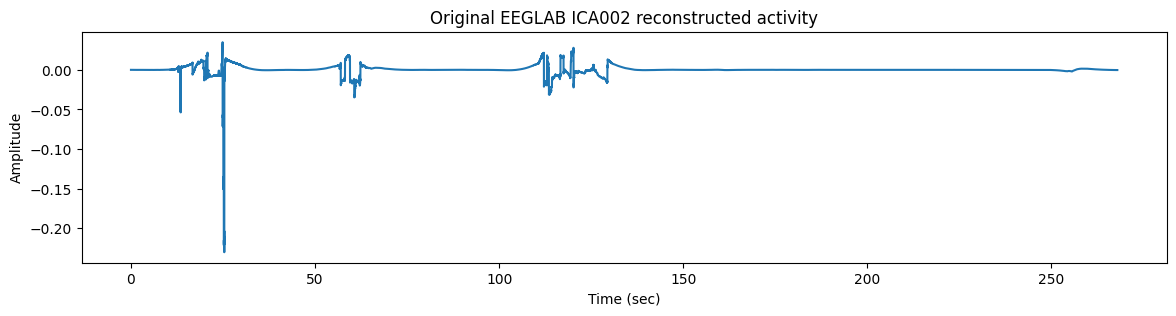

In [294]:
fs = raw.info["sfreq"]
times = np.arange(icaact_reconstructed.shape[1]) / fs

for i in range(icaact_reconstructed.shape[0]):

    plt.figure(figsize=(14, 3))
    plt.plot(times, icaact_reconstructed[i])

    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.title(f"Original EEGLAB ICA{i:03d} reconstructed activity")

    plt.show()

#Plotted the reconstructed original EEGLAB ICA component activity over time

In [295]:
ica_breath = mne.filter.filter_data(
    icaact_reconstructed,
    sfreq=fs,
    l_freq=0.1,
    h_freq=0.4,
    verbose=True
)

print("Respiration-band EEGLAB ICA shape:", ica_breath.shape)

# Filtered the original EEGLAB ICA activity into the respiration frequency band: 0.1–0.4 Hz.

Setting up band-pass filter from 0.1 - 0.4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 0.40 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.40 Hz)
- Filter length: 8251 samples (33.004 s)

Respiration-band EEGLAB ICA shape: (3, 66975)


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


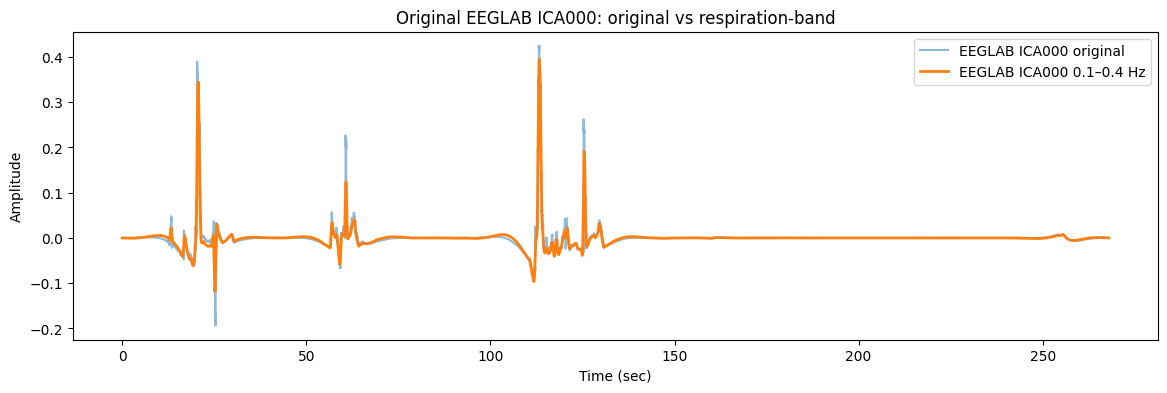

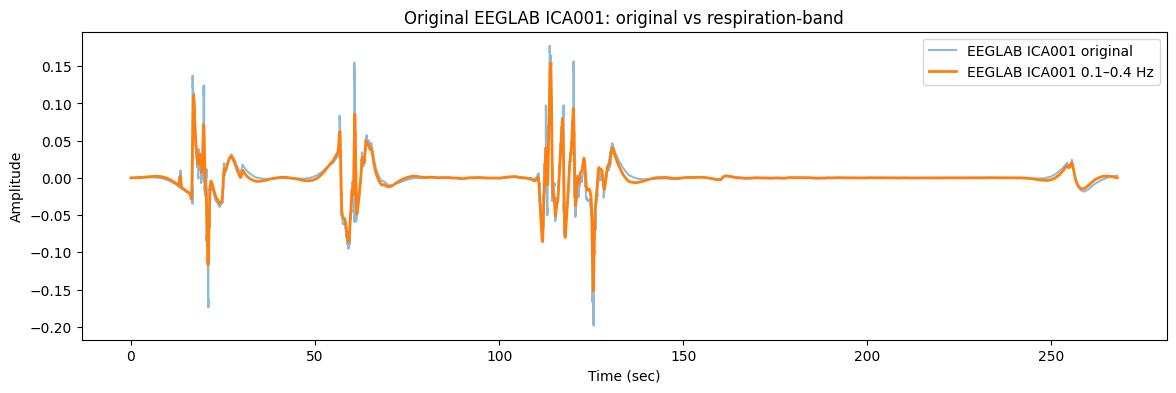

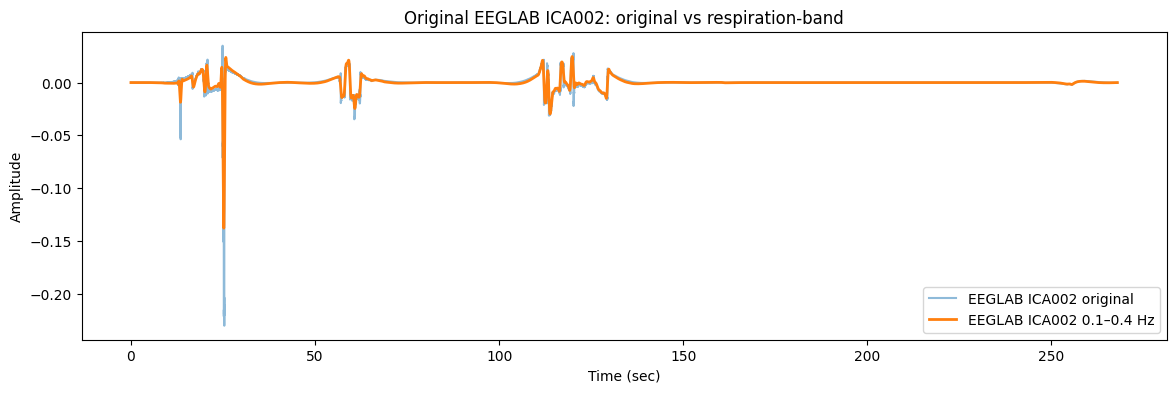

In [301]:
for i in range(icaact_reconstructed.shape[0]):

    plt.figure(figsize=(14, 4))

    plt.plot(times, icaact_reconstructed[i], label=f"EEGLAB ICA{i:03d} original", alpha=0.5)
    plt.plot(times, ica_breath[i], label=f"EEGLAB ICA{i:03d} 0.1–0.4 Hz", linewidth=2)

    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.title(f"Original EEGLAB ICA{i:03d}: original vs respiration-band")
    plt.legend()
    plt.show()

#Plotted respiration-band ICA activity to visually inspect whether any ICA component showed slow breathing-like oscillations

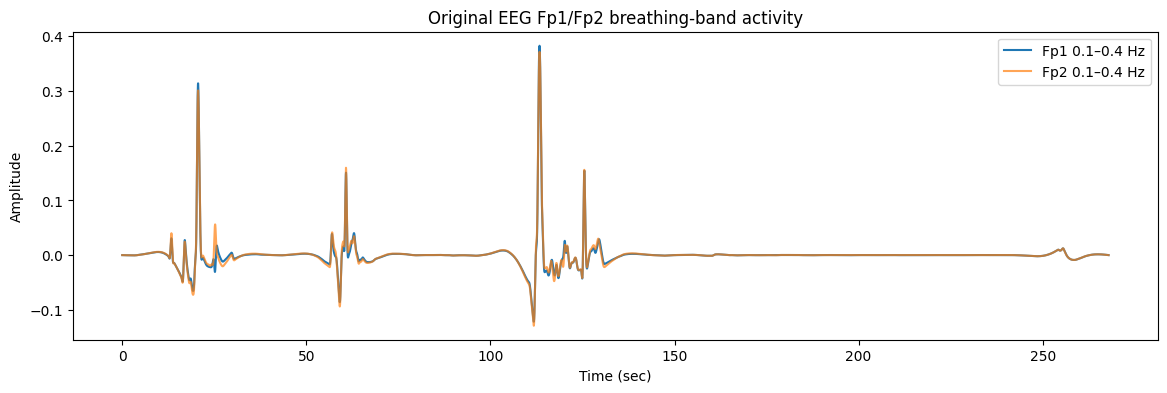

In [297]:
plt.figure(figsize=(14, 4))

plt.plot(times, fp_breath_data[0], label="Fp1 0.1–0.4 Hz")
plt.plot(times, fp_breath_data[1], label="Fp2 0.1–0.4 Hz", alpha=0.7)

plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.title("Original EEG Fp1/Fp2 breathing-band activity")
plt.legend()
plt.show()

#took (Fp1, Fp2) keep only 0.1–0.4 Hz frequencies (breathing band) plot slow oscillations over time

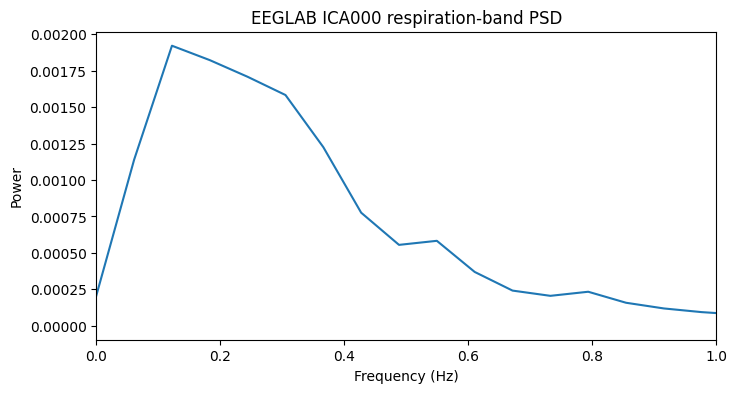

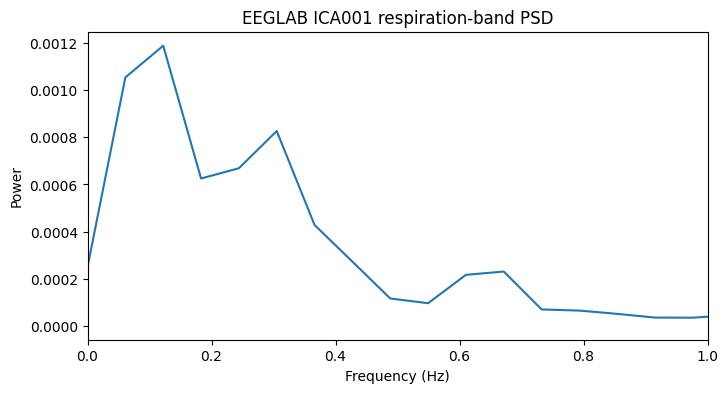

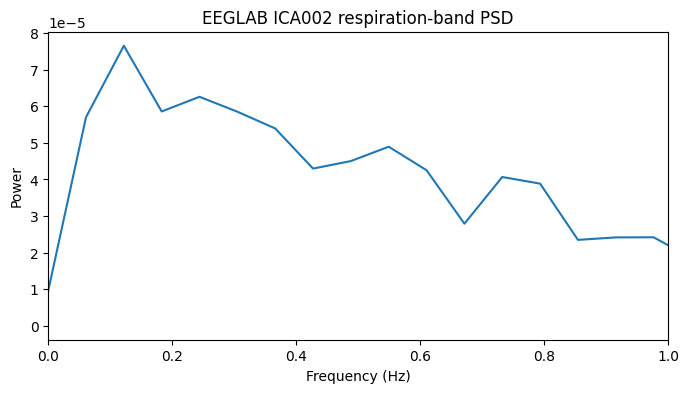

In [303]:
for i in range(ica_breath.shape[0]):

    freqs, psd = welch(
        ica_breath[i],
        fs=fs,
        nperseg=4096
    )

    plt.figure(figsize=(8, 4))
    plt.plot(freqs, psd)

    plt.xlim(0, 1)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title(f"EEGLAB ICA{i:03d} respiration-band PSD")

    plt.show()

# Ran PSD/DSP analysis on the respiration-band ICA signals. Looked for power peaks in the breathing-frequency range/#
    #Computed PSD (Welch) on respiration-band ICA signals. Checked for power in breathing-frequency range.

In [299]:
# Fp1/Fp2 breathing-band Step 13: Computed PSD on Fp1/Fp2 respiration-band signals.

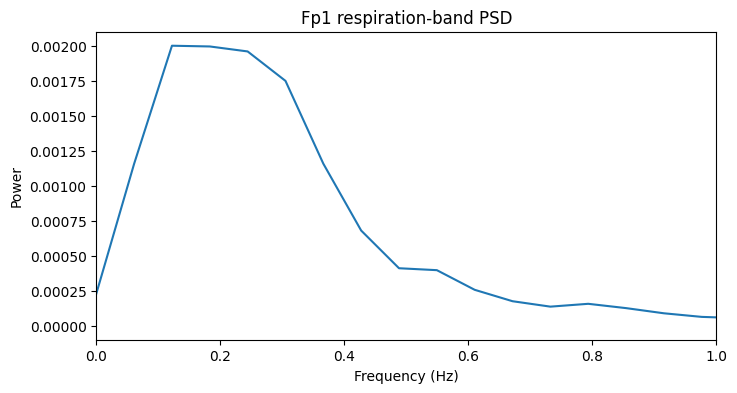

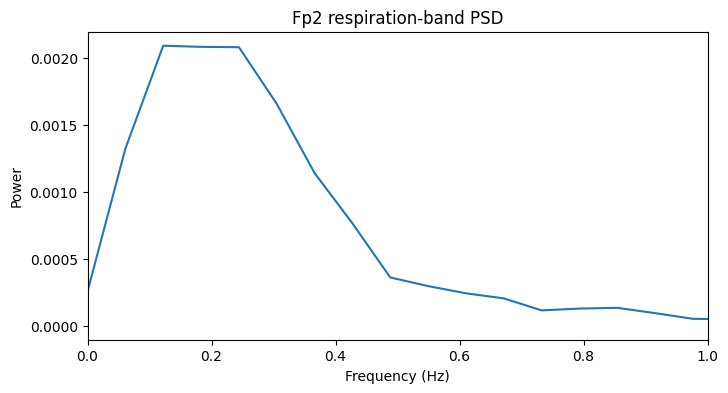

In [300]:
for ch_name, sig in zip(raw_fp_breath.ch_names, fp_breath_data):

    freqs, psd = welch(
        sig,
        fs=fs,
        nperseg=4096
    )

    plt.figure(figsize=(8, 4))
    plt.plot(freqs, psd)

    plt.xlim(0, 1)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title(f"{ch_name} respiration-band PSD")

    plt.show()